### California Housing Price Prediction

**Feature Description**

| Feature | Description |
|---|---|
| **MedInc** | Median household income within the block group |
| **HouseAge** | Median age of houses within the block group |
| **AveRooms** | Average number of rooms per household |
| **AveBedrms** | Average number of bedrooms per household |
| **Population** | Total population of the block group |
| **AveOccup** | Average number of household members |
| **Latitude** | Geographic latitude of the block group |
| **Longitude** | Geographic longitude of the block group |

In [362]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Load and basic inspection**

In [363]:
# load the data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseVal"] =housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [364]:
# shape of the data
df.shape

(20640, 9)

In [365]:
# info about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [366]:
# summary statsics about the data
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: xlabel='MedHouseVal', ylabel='Count'>

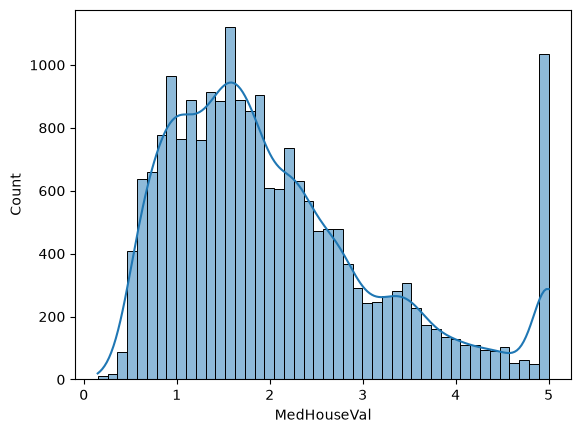

In [367]:
sns.histplot(df['MedHouseVal'], kde=True)

**Split the data into train, val and test**

In [368]:
# split into 60 - 20 -20
n = len(df)
n_test = int(n *0.2)
n_val = int(n *0.2)
n_train = n - n_test - n_val
n , n_test, n_val, n_train

# divide and shuffle the data
np.random.seed(42)
idx_shuffled = np.arange(n)
np.random.shuffle(idx_shuffled)

df_train = df.iloc[idx_shuffled[:n_train]]
df_test = df.iloc[idx_shuffled[n_train : n_train + n_test]]
df_val = df.iloc[idx_shuffled[n_train + n_test:]]

# drop the index
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [369]:
df_val.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.0278,33.0,5.458150,1.101322,648.0,2.854626,37.13,-120.26,0.588
1,2.4732,26.0,4.356736,1.081594,1415.0,2.685009,33.86,-117.91,1.658
2,2.3214,48.0,4.367901,1.059259,993.0,2.451852,34.04,-118.36,1.394
3,3.2500,32.0,5.220884,0.939759,712.0,2.859438,34.69,-118.15,1.075
4,3.1806,24.0,7.925926,1.712963,388.0,3.592593,38.93,-119.97,1.072


In [370]:
# seprate the target features
y_train = df_train.MedHouseVal
y_test = df_test.MedHouseVal
y_val = df_val.MedHouseVal

In [371]:
# drop the MedHouseVal
df_train = df_train.drop(["MedHouseVal"], axis=1)
df_test = df_test.drop(["MedHouseVal"], axis=1)
df_val= df_val.drop(["MedHouseVal"], axis=1)

**Train the model**

In [372]:
def train_linear_regression(X, y):
    m = len(X)
    ones = np.ones(m)
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [373]:
def RMSE(y , y_pred):
    error = y - y_pred
    se = error** 2
    mse = se.mean()
    return np.sqrt(mse)

**Base line model**

In [374]:
y_pred = y_train.mean()
RMSE(y_train, y_pred)

np.float64(1.1516120668172483)

In [375]:
def prepare_X(df):
    df = df.values
    return df

In [376]:
X_train = prepare_X(df_train)
w0 , w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)
y_pred

array([0.71549053, 1.76391344, 2.70707048, ..., 0.94456865, 1.78406937,
       2.97104828], shape=(12384,))

In [377]:
def RMSE(y , predication):
    error = y - predication
    se = error** 2
    mse = se.mean()
    return np.sqrt(mse)

In [378]:
# RMSE on training set
RMSE(y_train, y_pred)

np.float64(0.7220923097725198)

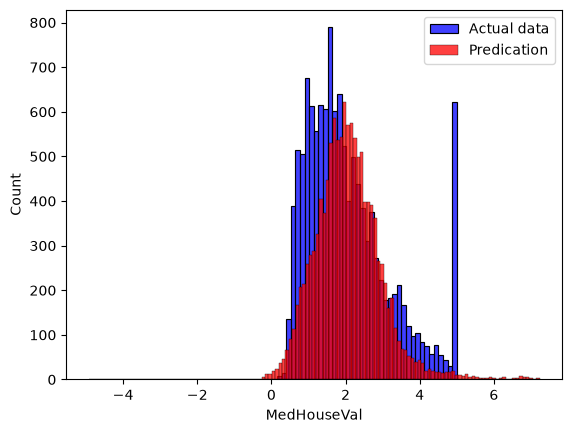

In [379]:
sns.histplot(y_train, label="Actual data", color='blue')
sns.histplot(y_pred, label="Predication", color="red")
plt.legend();

**Validate our model**

In [380]:
X_val = prepare_X(df_val)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)

In [381]:
train_rmse = RMSE(y_train, w0 + X_train.dot(w))
val_rmse = RMSE(y_val, y_pred)

print("Train RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Train RMSE: 0.7220923097725198
Validation RMSE: 0.784985811603127


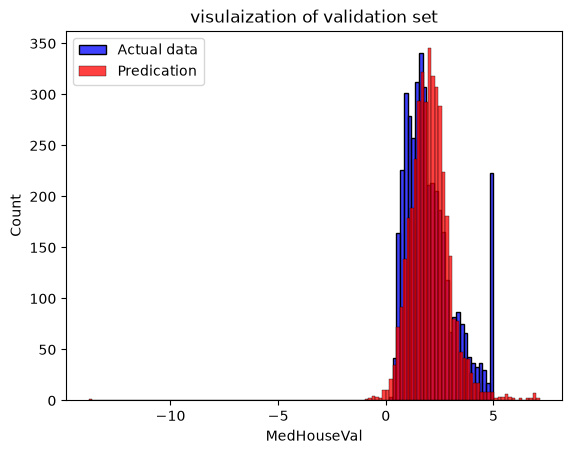

In [382]:
sns.histplot(y_val, label="Actual data", color='blue')
sns.histplot(y_pred, label="Predication", color="red")
plt.title("visulaization of validation set")
plt.legend();